In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gzip

warnings.filterwarnings("ignore")

In [2]:
TRAIN_PATH = "/kaggle/input/competitions/avazu-ctr-prediction/train.gz"
SAMPLE_SIZE = 1000000
RANDOM_SEED = 42

In [3]:
COL_NOTES = {
    "id":           "Ad identifier (unique per row)",
    "click":        "Target: 1 = clicked, 0 = not clicked",
    "hour":         "YYMMDDHH format — encodes date AND hour",
    "C1":           "Anonymized categorical",
    "banner_pos":   "Position of the banner on the page",
    "site_id":      "Site identifier",
    "site_domain":  "Domain the site belongs to",
    "site_category":"Category of the site",
    "app_id":       "App identifier",
    "app_domain":   "Domain of the app",
    "app_category": "Category of the app",
    "device_id":    "Device identifier (very high cardinality)",
    "device_ip":    "IP address (very high cardinality)",
    "device_model": "Device model",
    "device_type":  "Type of device (phone/tablet/…)",
    "device_conn_type": "Connection type (wifi/3g/…)",
    "C14–C21":      "Anonymized categoricals",
}

for k,v in COL_NOTES.items():
    print(f"{k:20s}:   {v}")

id                  :   Ad identifier (unique per row)
click               :   Target: 1 = clicked, 0 = not clicked
hour                :   YYMMDDHH format — encodes date AND hour
C1                  :   Anonymized categorical
banner_pos          :   Position of the banner on the page
site_id             :   Site identifier
site_domain         :   Domain the site belongs to
site_category       :   Category of the site
app_id              :   App identifier
app_domain          :   Domain of the app
app_category        :   Category of the app
device_id           :   Device identifier (very high cardinality)
device_ip           :   IP address (very high cardinality)
device_model        :   Device model
device_type         :   Type of device (phone/tablet/…)
device_conn_type    :   Connection type (wifi/3g/…)
C14–C21             :   Anonymized categoricals


### Step 1: Loading Sample

In [4]:
with gzip.open(TRAIN_PATH,'rb') as f:
    total_rows = sum(1 for _ in f)

print("Total number of rows:", total_rows)

Total number of rows: 40428968


In [5]:
skip_prob = 1-(SAMPLE_SIZE/total_rows)
skip_rows = np.random.RandomState(RANDOM_SEED).choice(
    range(1,total_rows+1),
    size = (total_rows-SAMPLE_SIZE),
    replace=False
)
print(skip_prob)

0.9752652602955386


In [6]:
df = pd.read_csv(TRAIN_PATH,skiprows=skip_rows)
print(f"Loaded sample of rows {df.shape[0]} and columns {df.shape[1]}")
df.head()

Loaded sample of rows 1000000 and columns 24


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,10000679056417042096,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157
1,10011205200760015892,0,14102100,1005,0,6256f5b4,28f93029,f028772b,ecad2386,7801e8d9,...,1,0,17212,320,50,1887,3,39,100202,23
2,10017756797097747189,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,1,0,20366,320,50,2333,0,39,-1,157
3,10027325869092401811,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15702,320,50,1722,0,35,100084,79
4,10028659945951062490,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79


### Step 2: Checks

In [7]:
df.dtypes

id                  uint64
click                int64
hour                 int64
C1                   int64
banner_pos           int64
site_id             object
site_domain         object
site_category       object
app_id              object
app_domain          object
app_category        object
device_id           object
device_ip           object
device_model        object
device_type          int64
device_conn_type     int64
C14                  int64
C15                  int64
C16                  int64
C17                  int64
C18                  int64
C19                  int64
C20                  int64
C21                  int64
dtype: object

In [8]:
df.isnull().sum()

id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dtype: int64

### STEP - 3 Target: click rate

In [9]:
click_rate = df['click'].mean()
click_rate

np.float64(0.169756)

In [10]:
print(f"Clicks {df['click'].sum()}")
print(f"Non clicks {(df['click']==0).sum()}")
print(f"\n Imbalance ratio: 1:{(1-click_rate)/click_rate:.1f}  ")

Clicks 169756
Non clicks 830244

 Imbalance ratio: 1:4.9  


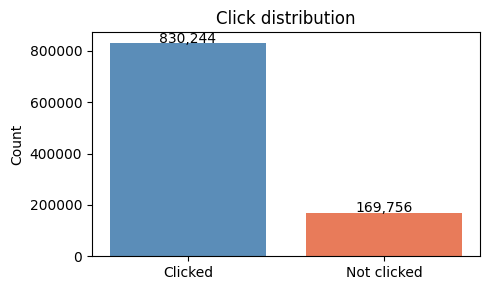

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Clicked','Not clicked'],df['click'].value_counts().sort_index(),color=["#5B8DB8", "#E87B5A"])
ax.set_title("Click distribution")
ax.set_ylabel("Count")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{bar.get_height():,.0f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### STEP 4 — Parse the `hour` column

In [12]:
df['hour_str'] = df['hour'].astype(str)
df['date'] = pd.to_datetime(df['hour_str'], format="%y%m%d%H")
df['hour_of_day'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['date_only'] = df['date'].dt.date
df['day'] = df['date'].dt.day

In [13]:
print("Date range in sample:")
print(f"  From: {df['date'].min()}")
print(f"  To:   {df['date'].max()}")

Date range in sample:
  From: 2014-10-21 00:00:00
  To:   2014-10-30 23:00:00


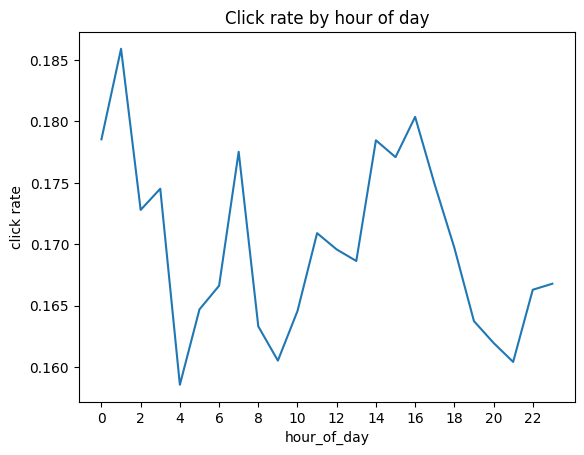

In [14]:
ctr_by_hour = df.groupby('hour_of_day')['click'].mean()
ctr_by_hour.plot()
plt.xticks(range(0, 24, 2))
plt.title("Click rate by hour of day")
plt.ylabel("click rate")
plt.show()

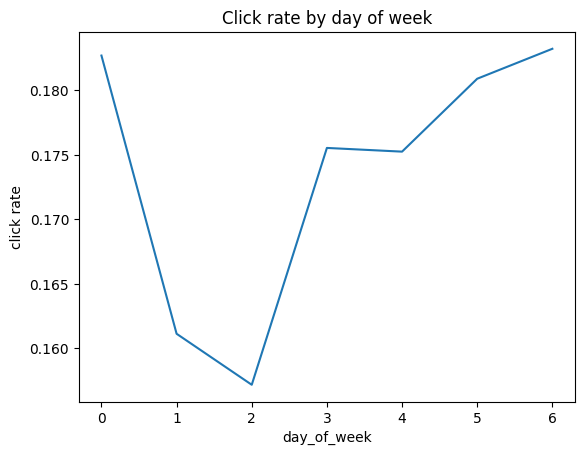

In [15]:
ctr_by_dayofweek = df.groupby("day_of_week")['click'].mean()
ctr_by_dayofweek.plot()
plt.xticks(range(0, 7, 1))
plt.title("Click rate by day of week")
plt.ylabel("click rate")
plt.show()

In [16]:
peak_hour = ctr_by_hour.idxmax()
print(f"\nPeak CTR hour: {peak_hour}:00  ({ctr_by_hour[peak_hour]:.3%})")
print(f"Lowest CTR hour: {ctr_by_hour.idxmin()}:00  ({ctr_by_hour.min():.3%})")


Peak CTR hour: 1:00  (18.592%)
Lowest CTR hour: 4:00  (15.855%)


### STEP 5 — Cardinality of categorical columns

In [17]:
cat_cols = [c for c in df.columns if c not in
            ["id","click","hour","hour_str","date","date_only","hour_of_day","day_of_week"]]

In [18]:
cardinality = pd.DataFrame({
    "columns":cat_cols,
    "unique_vals": [df[c].nunique() for c in cat_cols]
}).sort_values(by='unique_vals')

cardinality

,columns,unique_vals
12,device_conn_type,4
17,C18,4
11,device_type,5
0,C1,7
1,banner_pos,7
14,C15,8
15,C16,9
21,day,10
4,site_category,21
7,app_category,26


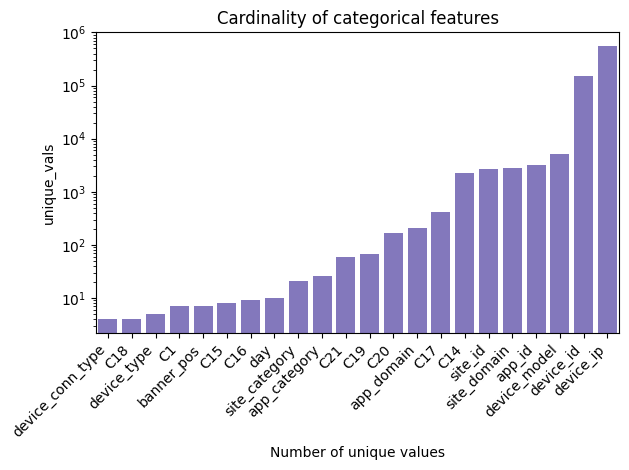

In [19]:
sns.barplot(data = cardinality,x="columns",y='unique_vals',color="#7B6CC8")
plt.yscale('log')
plt.xticks(rotation=45,ha='right')
plt.xlabel("Number of unique values")
plt.title("Cardinality of categorical features")
plt.tight_layout()
plt.show()

### STEP 6 — CTR per category (which features drive clicks most?)

In [20]:
feature_signal = {}

for col in cat_cols:
    if df[col].nunique() < 5000:
        ctr_per_cat = df.groupby(col)['click'].mean()
        feature_signal[col] = ctr_per_cat.std()

signaldf = pd.Series(feature_signal).sort_values(ascending=False)
signaldf.round(4)

app_domain          0.2818
app_id              0.2786
site_domain         0.2734
site_id             0.2439
C14                 0.1740
C16                 0.1442
C15                 0.1436
C17                 0.1283
site_category       0.1242
C18                 0.1069
app_category        0.0870
C19                 0.0869
device_type         0.0810
C21                 0.0763
C20                 0.0754
device_conn_type    0.0721
C1                  0.0665
banner_pos          0.0607
day                 0.0118
dtype: float64

In [21]:
print(" CTR by banner_pos ")
print(df.groupby("banner_pos")["click"].agg(["mean","count"]).rename(columns={"mean":"ctr"}))

 CTR by banner_pos 
                 ctr   count
banner_pos                  
0           0.164406  720094
1           0.183080  278091
2           0.146179     301
3           0.153846      39
4           0.156566     198
5           0.142857     161
7           0.314516    1116


In [22]:
print(" CTR by device_type ")

print(df.groupby("device_type")["click"].agg(["mean","count"]).rename(columns={"mean":"ctr"}))

 CTR by device_type 
                  ctr   count
device_type                  
0            0.209672   54924
1            0.169199  922688
2            0.000000       2
4            0.096162   19072
5            0.086904    3314


In [23]:
print(" CTR by device_conn_type ")
print(df.groupby("device_conn_type")["click"].agg(["mean","count"]).rename(columns={"mean":"ctr"}))

 CTR by device_conn_type 
                       ctr   count
device_conn_type                  
0                 0.181119  862959
2                 0.134419   81990
3                 0.044533   53982
5                 0.030870    1069


### STEP 7 — Site vs App: which channel drives more clicks?

In [24]:
print(df['app_id'].value_counts().head())
print(df['site_id'].value_counts().head())

app_id
ecad2386    638469
92f5800b     38501
e2fcccd2     28235
febd1138     18782
9c13b419     18780
Name: count, dtype: int64
site_id
85f751fd    361531
1fbe01fe    160269
e151e245     65511
d9750ee7     23633
5b08c53b     22727
Name: count, dtype: int64


              ctr    count
channel                   
App      0.169756  1000000


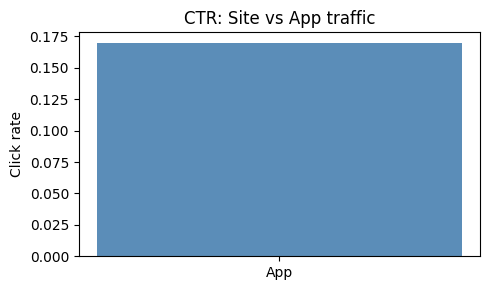

In [25]:
NULL_HASH = "85f751fd"  # Avazu uses this hash for the absent channel
df["is_app"] = (df["app_id"] != NULL_HASH).astype(int)
df["channel"] = df["is_app"].map({1: "App", 0: "Site"})
 
print(df.groupby("channel")["click"].agg(["mean","count"]).rename(columns={"mean":"ctr"}))
 
fig, ax = plt.subplots(figsize=(5, 3))
channel_ctr = df.groupby("channel")["click"].mean()
ax.bar(channel_ctr.index, channel_ctr.values, color=["#5B8DB8","#E87B5A"])
ax.set_title("CTR: Site vs App traffic")
ax.set_ylabel("Click rate")
plt.tight_layout()
plt.savefig("eda_step7_site_vs_app.png", dpi=120)
plt.show()

In [26]:
df['channel'].unique()

array(['App'], dtype=object)

### STEP 9 — Correlation between anonymized C-features and CTR

In [27]:
for col in ['site_id','app_id','device_id']:
    vc = df[col].value_counts()
    rare = (vc>10).sum()
    print(f"{col:20s}: {vc.shape[0]:6,} unique values, "
          f"{rare:6,} appear <10 times ({rare/vc.shape[0]:.1%})")

site_id             :  2,677 unique values,  1,122 appear <10 times (41.9%)
app_id              :  3,143 unique values,    875 appear <10 times (27.8%)
device_id           : 150,683 unique values,    136 appear <10 times (0.1%)


In [28]:
c_cols = [col for col in df.columns if col.startswith("C")]

c_signal = {}

for col in c_cols:
    if df[col].nunique() < 5000:
        c_signal[col] = df.groupby(col)['click'].mean().std()

c_signal

{'C1': 0.066456910459955,
 'C14': 0.17401649201796707,
 'C15': 0.14359177751226734,
 'C16': 0.1441617723150186,
 'C17': 0.12827841594052733,
 'C18': 0.10687290362452781,
 'C19': 0.08690461202025547,
 'C20': 0.075364024425311,
 'C21': 0.07630236789755462}

In [29]:
c_signal_df = pd.Series(c_signal).sort_values(ascending=False)
print(c_signal_df.round(4))

C14    0.1740
C16    0.1442
C15    0.1436
C17    0.1283
C18    0.1069
C19    0.0869
C21    0.0763
C20    0.0754
C1     0.0665
dtype: float64


### Step 11 — Time-based validation split

In [30]:
df['day'].unique()

array([21, 22, 23, 24, 25, 26, 27, 28, 29, 30], dtype=int32)

##### Since there are 10 days data in dataset, lets put 9 days ( from 21st to 29th ) as training and last day (30th) as testing

In [31]:
train = df[df['day']<=29]
val = df[df['day']==30]

In [32]:
print(f"Length of training set: {len(train)}")
print(f"Length of validation set: {len(val)}")

Length of training set: 895806
Length of validation set: 104194


### Step 12 — Baseline model (Logistic Regression)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss

In [34]:
BASE_FEATURES = [
    "C1", "banner_pos", "site_category", "app_category",
    "device_type", "device_conn_type", "C15", "C16", "C18",
    "hour_of_day", "day_of_week"
]

In [35]:
X_train = train[BASE_FEATURES]
X_val = val[BASE_FEATURES]

In [36]:
for col in X_train.select_dtypes("object").columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype('str'))
    X_val[col] = X_val[col].astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

In [37]:
Y_train = train['click']
Y_val = val['click']

In [38]:
model = LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

In [39]:
val_preds = model.predict_proba(X_val)[:, 1]
score = log_loss(Y_val, val_preds)
print(f"Baseline log loss: {score:.5f}")

Baseline log loss: 0.45129


In [40]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,C20,C21,hour_str,date,hour_of_day,day_of_week,date_only,day,is_app,channel
0,10000679056417042096,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,-1,157,14102100,2014-10-21,0,1,2014-10-21,21,1,App
1,10011205200760015892,0,14102100,1005,0,6256f5b4,28f93029,f028772b,ecad2386,7801e8d9,...,100202,23,14102100,2014-10-21,0,1,2014-10-21,21,1,App
2,10017756797097747189,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,-1,157,14102100,2014-10-21,0,1,2014-10-21,21,1,App
3,10027325869092401811,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,100084,79,14102100,2014-10-21,0,1,2014-10-21,21,1,App
4,10028659945951062490,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,100084,79,14102100,2014-10-21,0,1,2014-10-21,21,1,App
